## Motivation
Spectral binning and hashing compress spectra into fixed slots, but neural networks benefit from knowing where a feature sits relative to others - not just its absolute coordinate. A clearer analogy:

- Imagine finding a book on a crowded shelf. Absolute coordinates (the coordinates of the book) tell you a global location, but they’re unreliable. What helps you actually grab the book are relative cues: “two books to the right of the blue cookbook” or “third from the top.” Those local relationships are robust and easy to act on.

- Positional encoding is like giving each peak many rulers with different tick spacings. Some rulers have very fine ticks (short wavelengths) so you can precisely tell two nearly identical locations apart; others have very coarse ticks (long wavelengths) so you know which region of the shelf you’re in. Combining both lets you both pinpoint small differences and understand broad structure.

- Concretely: Each peak in a spectrum can be represented by wavelengths acting as repeating landmarks at multiple scales. Fine wavelengths capture tiny m/z shifts (isotopes, noise), coarse wavelengths capture large scale patterning (different peptides or charge states). This multi scale representation makes it easier for models to both discriminate nearby peaks and reason about overall spectral structure.

![Each m/z value, m_j, is projected into 512 dimensions](CasanovoEncoding.png)

Positional encoding, as outlined in the Casanovo paper. D = 512

Alright. That's outrageously complicated. Let's break that equation down into digestible parts. Do you remember this? It's the equation for creating sine wavelengths given a few values that you might've seen in your high school Algebra class.


$$
y = A\sin\big(B(x - h)\big) + k
$$

$$
\begin{aligned}
\text{Amplitude} &= |A|, \\
\text{Midline} &= y=k, \\
\text{Period} &= \frac{2\pi}{|B|}\ \text{ (or } \frac{360^\circ}{|B|}\text{)}, \\
\text{Phase shift} &= 
\begin{cases}
\text{right } h & \text{if } (h < 0),\\
\text{left } h & \text{if } (h > 0).
\end{cases}
\end{aligned}
$$


### Numerical Example

Even though I haven't introduced our usecase, consider a seemingly randomly generated sine wave: $\sin\left(\frac{x}{(0.001/2\pi)(10,000/0.001)^{1/2}}\right)$ where we can calculate our period as:
$$ 
\text{Period} = \frac{2\pi}{B} \text{ where } B = \frac{1}{\left(\frac{0.001}{2\pi}\right)\left(\frac{10000}{0.001}\right)^{1/2}} = 2\pi \times \left(\frac{0.001}{2\pi}\right) \times 3162.277 = 3.162277
$$
So, this sine wave goes through one crest and one trough till it hits some point $(x,y)$ again. I.e. the wave starts at, say $x = 0$, and "restarts" at $x = 3.162\dots$. You might recall crest -> crest being a period, or trough -> trough being a period.

![image-2.png](desmos_1.png)
A single period plotted for this sine wave

### Wavelengths

For the second time, I'll throw something at you without expecting you to understand any of it. Now imagine an arbitrary list of numbers spanning from $0.001$ to $10000$, increasing exponentially. This list contains exactly **256 values** - we'll call them our **wavelengths** $\lambda_i$ where i $\in I$ is the index set from 1 through 256. Take this for granted for now, and we'll slowly build up rationale for this list. So thus far, we have: $\lambda = [0.001, \dots, 10000]$. 

Finally, we'll take a stab at the actual equation.

## Breaking Down the Formula

Let's start simple: we'll focus on just the sine component of the piecewise equation.

That turns the equation we'll focus on to:

$$
f_i(m_j) = \sin\left(\frac{m_j}{(\lambda_{\min}/2\pi)\times(\lambda_{\max}/\lambda_{\min})^{i/\dim-1}}\right) \quad \text{for } i < 256
$$

- $m_j$ is the $j$-th peak's $m/z$ value
- $f_i$ defines the encoding for peak $m_j$
- $\dim$ defines the number of dimensions we'll encode a single peak in.
- $i$ defines the current dimension we're encoding in
- $\lambda_{\min} \text{ and } \lambda_{\max}$ define the range of "wavelengths" we will end up encoding each peak in. How we pick these still needs to be discussed.

Note then, that we can simplify

$(\lambda_{\min}/2\pi)\times(\lambda_{\max}/\lambda_{\min})^{i/\dim-1} \Longrightarrow \quad \lambda_i \quad \text{for } i \in I $


We rewrite for each wavelength:

$$
f_i(m_j) = \sin\left(\frac{m_j}{\lambda_i}\right) \quad \text{for } i < 256
$$

where:
- $\lambda_i$ is the $i$-th wavelength for a given peak, $m_j$ 
    - Concretely, $\lambda_i$ is the denominator of the argument. In our numerical example we used $i=128$; considering just the sine portion (256 dimensions), $128/256=\tfrac{1}{2}$. More precisely,

    $$\lambda_i = \left(\frac{\lambda_{\min}}{2\pi}\right)\left(\frac{\lambda_{\max}}{\lambda_{\min}}\right)^{\frac{i}{d_{\sin}-1}}$$
    and thus

    $$
    \sin\!\left(\frac{x}{\lambda_{128}}\right)
    =
    \sin\!\left(\frac{x}{\left(\frac{0.001}{2\pi}\right)\left(\frac{10000}{0.001}\right)^{1/2}}\right).
    $$

Note that $2\pi$ appears in the denominator of the wavelength formula? This is actually quite elegant. When we calculate the period of our sine wave using the standard formula $\text{Period} = 2\pi/B$, where $B$ is the coefficient of $x$ in our sine function, something interesting happens.

Recall that our sine function is $\sin(m_j/\lambda_i)$, which means $B = 1/\lambda_i$. Therefore:

$$
\text{Period} = 2\pi \times \lambda_i = 2\pi \times \left(\frac{\lambda_{\min}}{2\pi}\right)\left(\frac{\lambda_{\max}}{\lambda_{\min}}\right)^{\frac{i}{d_{\sin}-1}}
$$

Notice how the $2\pi$ in the period formula cancels with the $2\pi$ in the denominator of $\lambda_i$. This simplification gives us:

$$
\text{Period} = \lambda_{\min} \times \left(\frac{\lambda_{\max}}{\lambda_{\min}}\right)^{\frac{i}{d_{\sin}-1}}
$$

This cleaner expression shows that the period is simply determined by the minimum wavelength scaled exponentially based on the current dimension index $i$. As $i$ increases from 0 to 255 (256 total values), the period grows exponentially from $\lambda_{\min}$ to $\lambda_{\max}$.


As promised, let's fill in the blanks now for each $\lambda_i$ using our formula. Because I don't want to compute 256 values, I'll show you a low dimensional example. 

$\lambda_i = \frac{\lambda_{\min}}{2\pi} \times \left(\frac{\lambda_{\max}}{\lambda_{\min}}\right)^{\frac{i}{5}}$

for $i = 0, 1, 2, 3, 4, 5$:

So, we now compute 6 different dimensions to make a _list_ of $\lambda_{i}$ 
$$
\begin{aligned}
\lambda_0 &= \frac{0.001}{2\pi} \times \left(\frac{10000}{0.001}\right)^{0/5} = \frac{0.001}{2\pi} \times 0.001 = \frac{0.001}{2\pi} \\
\lambda_1 &= \frac{0.001}{2\pi} \times \left(\frac{10000}{0.001}\right)^{1/5} = \frac{0.001}{2\pi} \times 15.848932 = \frac{0.0158}{2\pi} \\
 \lambda_2 &= \frac{0.001}{2\pi} \times \left(\frac{10000}{0.001}\right)^{2/5} = \frac{0.001}{2\pi} \times 251.188643151 = \frac{0.251}{2\pi} \\
\lambda_3 &= \frac{0.001}{2\pi} \times \left(\frac{10000}{0.001}\right)^{3/5} = \frac{0.001}{2\pi} \times 3981.07170553 = \frac{3.981}{2\pi} \\
\lambda_4 &= \frac{0.001}{2\pi} \times \left(\frac{10000}{0.001}\right)^{4/5} = \frac{0.001}{2\pi} \times 63095.734448 = \frac{63.095}{2\pi} \\
\lambda_5 &= \frac{0.001}{2\pi} \times \left(\frac{10000}{0.001}\right)^{5/5} = \frac{0.001}{2\pi} \times 1000000 = \frac{10}{2\pi}
\end{aligned}
$$

Here we chose dimensions that just so happened to multiply by 10 at each step. If we do 6 dimensions, this pattern falls apart. 
The concept of what $\lambda_i$ actually *is* may still not be clear to you. Here's what clicked for me

### The Full Encoding

In this abstraction, We have **512 dimensions** to encode each peak, 256 for sine, 256 for cosine:


```python
for i in range(dimensions / 2):          # First 256 dimensions: sine. i = 0-> 255
    for j in spectrum_peak_list:
        encoding[i][j] = sin(m_j / wavelength[i])

for i in range(dimensions / 2, dimensions):  # Next 256 dimensions: cosine
    for j in spectrum_peak_list:
        encoding[i][j] = cos(m_j / wavelength[i - 256]) 
        # note: we still only consider wavelengths [0 -> 256], just from encoding[256->512][j]
```
### Low Dimensional Example

Let's try keeping our max and min the same, but encode each peak with only 5 dimensions (5 sine waves). Again, ignore the cosine portion for now. 

Still, this is difficult to decode. Note that $x$ represents a peak at some m/z value:

<img src="image2.png" alt="image2" width="1200"/>

Let's zoom in to see all parts clearly:


<img src="image.png" alt="image1" width="500"/>

As you can see, the red wave is oscillating so fast that it just looks like one amorphous blob when we zoom out. The rest are more human visible. 

Take m/z = 600. I've made the red wave at dimension 1/5 invisible for now, but you're welcome to write the equations in, and I'll leave the desmos permalink below. I also wrote in the point at which the red wave intersected x=600 as well.

![image3.png](image3.png)

Now that we have these 5 waves, I want to try and explain things visually


> **Note:** Here's an understanding check for you. Why didn't we graph $\lambda_0$ even though our values range from 0-> 5?

<details>
<summary>Click to see answer</summary>

The wavelength at $i=0$ is $\lambda_0 = \frac{0.001}{2\pi}$, which is extremely small. This creates a sine wave that oscillates so rapidly at the scale of typical m/z values (like 600) that it becomes practically invisible—just a blur. For visualization purposes, it's not informative, so we omitted it from the plot to keep the focus on the more meaningful wavelengths that show clear oscillation patterns.
</details>

Also, as promised, here's the desmos link used for all graphs: https://www.desmos.com/calculator/he8fjmng6v


## How Each Wave Changes: From m/z = 600 to 600.1 to 601

Let's trace what happens to each of the 5 waves as we move along the m/z axis. Looking at the graph, we have 5 sine waves with different periods:

### Wave 1 (Red, finest): Period ≈ 0.0158489319246
This wave oscillates **incredibly fast**. In the span from 600 to 601:
- It completes roughly **63 full cycles** (since $1 / 0.0158489319246 \approx 63.095734448$)
- From 600 to 600.1, it travels about **6 full cycles** ($0.1 / 0.0158489319246$)
- However, we care most about the likely massive y value difference. Our model can't calculate how many cycles have passed. 
- Even tiny m/z shifts cause major vertical jumps on this wave. If we had 

### Wave 2 (Green): Period ≈ 0.251188643151
This wave is slower. From 600 -> 601:
- It completes about 4 waves ($1/(~1/4) \approx 4$)
- From 600 to 600.1, it barely budges, as you can see above
- **Visual effect**: Small m/z changes (like 0.1) are nearly invisible; larger shifts (like 1.0) show gentle, gradual changes

### Wave 3 (Purple): Period ≈ 3.98107170553
Significantly slower again. From 600 to 601:
- It completes a quarter of a wave
- From 600 to 600.1, it completes ~$0.025$ waves. This is barely noticable to the model, and the y barely changes again, I recommend you reference each point with the diagram for a visual understanding.

### Wave 4 (Black): Period ≈ 63.095734448
From 600 to 601:
- Completes 1/63 waves
- From 600 to 600.1, it completes 1/630 waves. An even smaller difference.

### Wave 5 (Blue, coarsest): Period ≈ 1000
This is the "continental shelf" wave. From 600 to 601:
- It completes **0.001 full cycles** - imperceptibly flat
- This wave essentially divides the entire m/z spectrum into just a few massive regions
- It can't distinguish 600 from 601, or really even 600 from 650.
- **Visual effect**: A mostly horizontal line across this entire region. 


This multi-scale representation means:
- **Fine waves** (red, green) act like a microscope - they distinguish isotopes and small m/z differences
- **Coarse waves** (blue, black) act like a map - they tell you what *region* of the spectrum you're in
- Together, they give the neural network both **"where am I exactly?"** (fine) and **"what neighborhood am I in?"** (coarse)


Here's a visual from 600 -> 601 _(red wave excluded)_
![600 to 601](relativeDifferences.png)
This essentially maps peaks 600 and 601 to their respective sine wave values at each wavelength $\lambda_i$ for $i = [1, 2, 3, 4, 5]$:

$$
\begin{aligned}
\text{Peak } m/z = 600: \quad &[\lambda_1, \lambda_2, \lambda_3, \lambda_4, \lambda_5] \\
&= [0.36421, -0.782482, -0.97337, -0.058771, -0.58779] \\[0.5em]
\text{Peak } m/z = 601: \quad &[\lambda_1, \lambda_2, \lambda_3, \lambda_4, \lambda_5] \\
&= [-0.226739, -0.70307, -0.22198, -0.15773, -0.59286]
\end{aligned}
$$

Throughout this explanation, you may have seen various references to "we'll just focus on the sine part of the equation for now" (see full positional encoding equation image for reference). This is mostly because the rationale for encoding in both sine and cosine is purely algebraic, and not very intuitive. 



In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def make_wavelengths_casanovo(d_model: int, lambda_min: float = 0.001, lambda_max: float = 10000) -> np.ndarray:
    """
    Generate wavelengths following the Casanovo formula:
    ꟛ_i = (ꟛ_min / 2π) * (ꟛ_max / ꟛ_min)^(i / (d_sin - 1))
    
    Args:
        d_model = number of sin/cos pairs to consider.
        lambda_min: minimum wavelength (default: 0.001, as in Casanovo)
        lambda_max: maximum wavelength (default: 10000, as in Casanovo)
    
    Returns: Array of d_model // 2 wavelengths
    """
    # d_model must be divisible by 2 so as to encode with cosine and sine.
    wavelengths = np.zeros(d_model // 2)
    for i in range(d_model//2):
        wavelengths[i] = (lambda_min / (2 * np.pi)) * (lambda_max / lambda_min) ** (i / (d_model//2 - 1))
    display("wavelengths:", wavelengths)
    return wavelengths

In [3]:
# Define positional encoding function used by Casanovo
# This function takes in 1 m/z value and returns a 512-dimensional positional encoding vector
# (this feels sort of like a reverse Fourier transform)
def positional_encoding(m_z, d_model = 512, lambda_min = 0.001, lambda_max = 10000):
    encoding = np.zeros(d_model)
    d_sin = int(d_model/2)
    d_cos = d_model - d_sin
    for d in range(d_sin):
        encoding[d] = np.sin(m_z / ( (lambda_min / (2 * np.pi) ) * (lambda_max / lambda_min)**(d/(d_sin - 1))))
    for d in range(d_sin, d_model):
        encoding[d] = np.cos(m_z / ( (lambda_min / (2 * np.pi) ) * (lambda_max / lambda_min)**((d - d_sin ) / (d_cos - 1))))
    return encoding


151.81954329540787

'and'

-13.132661523959268

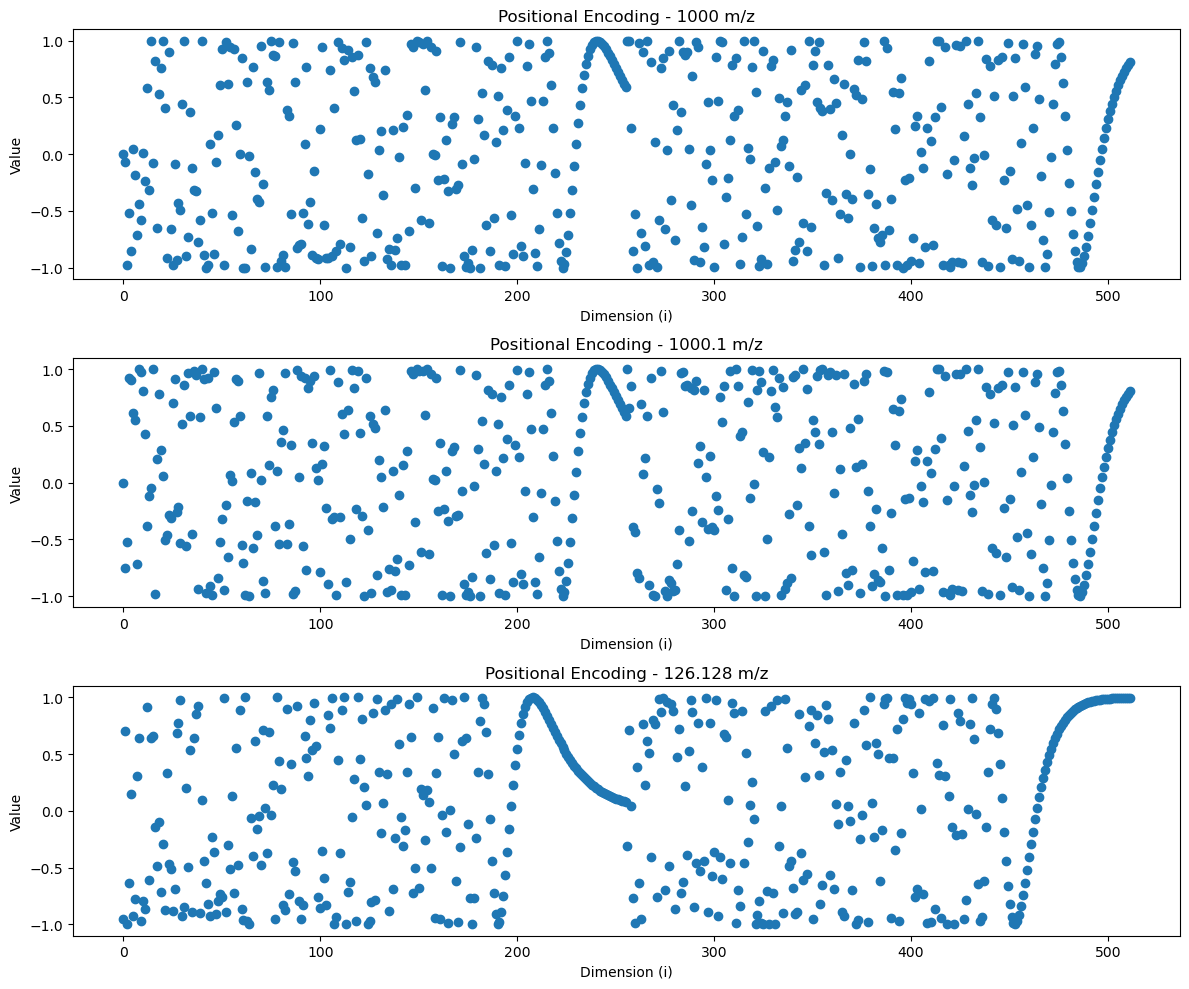

In [4]:
encode_1 = positional_encoding(1000)
encode_2 = positional_encoding(1000.1)
encode_3 = positional_encoding(126.1277)
for i in range(50,2000):
    positional_encoding(i)
display(np.dot(positional_encoding(1000),(positional_encoding(1000.1))), "and", np.dot(positional_encoding(1000),positional_encoding(126.127)))

# plot the encodings as three scatter plots,

# Set the figure size before creating subplots
plt.figure(figsize=(12, 10))

plt.subplot(3, 1, 1)
plt.scatter(range(len(encode_1)), encode_1)
plt.title("Positional Encoding - 1000 m/z")
plt.xlabel("Dimension (i)")
plt.ylabel("Value")

plt.subplot(3, 1, 2)
plt.scatter(range(len(encode_2)), encode_2)
plt.title("Positional Encoding - 1000.1 m/z")
plt.xlabel("Dimension (i)")
plt.ylabel("Value")

plt.subplot(3, 1, 3)
plt.scatter(range(len(encode_3)), encode_3)
plt.title("Positional Encoding - 126.128 m/z")
plt.xlabel("Dimension (i)")
plt.ylabel("Value")

plt.tight_layout()
plt.show()


I only halfway understand what's going on here, so the following explanation should be taken with a grain of salt

The positional encoding attempts to capture both high-resolution information and low-resolution information.

Dimensions ~200-255 and ~450-500 capture low resolution information. They will only differ if there is a large m/z difference between the encoded values.

Dimensions 0-50 and 256-300 encoded high resolution information. They change even if the m/z values are very close together

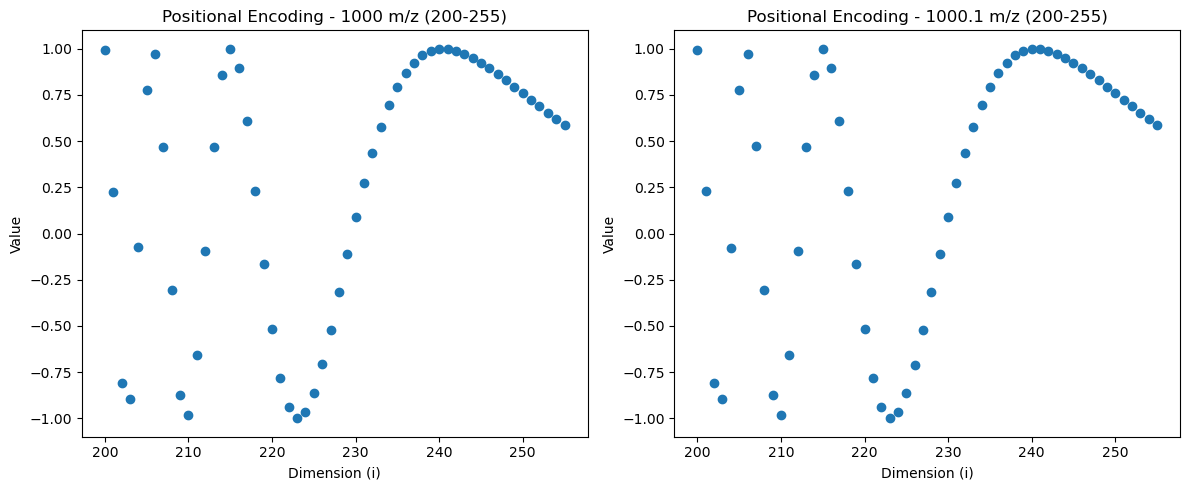

Cosine Similarity (1000 m/z vs 1000.1 m/z): 0.9999997415834383


In [5]:
# for encode_1 and encode_2, plot the values from 200 to 255
# and calculate the cosine similarity between the two
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(range(200, 256), encode_1[200:256])
plt.title("Positional Encoding - 1000 m/z (200-255)")
plt.xlabel("Dimension (i)")
plt.ylabel("Value")

plt.subplot(1, 2, 2)
plt.scatter(range(200, 256), encode_2[200:256])
plt.title("Positional Encoding - 1000.1 m/z (200-255)")
plt.xlabel("Dimension (i)")
plt.ylabel("Value")

plt.tight_layout()
plt.show()
from sklearn.metrics.pairwise import cosine_similarity

# Calculate cosine similarity between the two encodings
cosine_sim = cosine_similarity([encode_1[200:256]], [encode_2[200:256]])
print("Cosine Similarity (1000 m/z vs 1000.1 m/z):", cosine_sim[0][0])

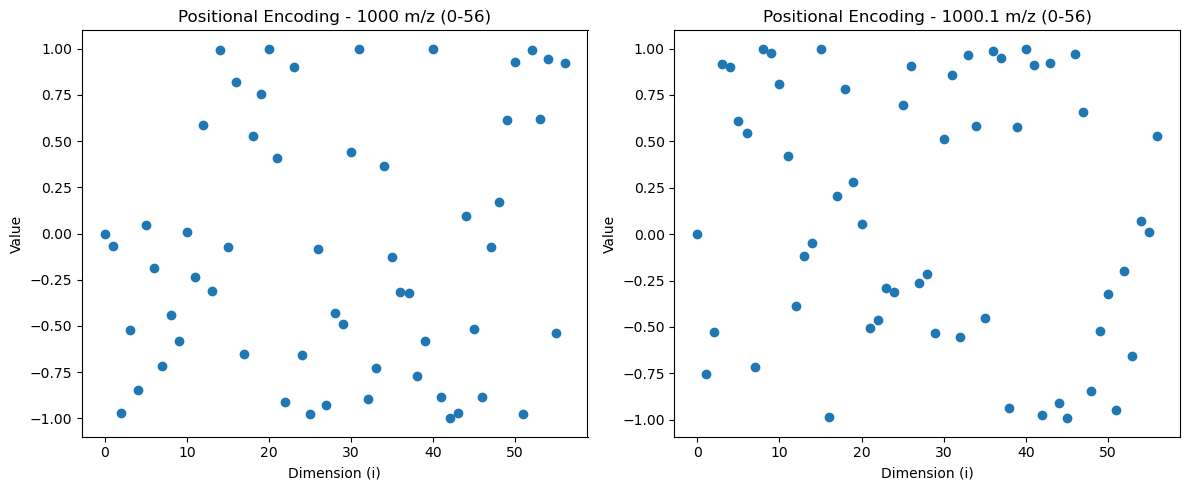

Cosine Similarity (1000 m/z vs 1000.1 m/z): -0.04100383952610734


In [6]:
# Repeat the above plots and calculations, but this time only consider the range from 0 to 56
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(range(0, 57), encode_1[0:57])
plt.title("Positional Encoding - 1000 m/z (0-56)")
plt.xlabel("Dimension (i)")
plt.ylabel("Value")

plt.subplot(1, 2, 2)
plt.scatter(range(0, 57), encode_2[0:57])
plt.title("Positional Encoding - 1000.1 m/z (0-56)")
plt.xlabel("Dimension (i)")
plt.ylabel("Value")

plt.tight_layout()
plt.show()

# Calculate cosine similarity between the two encodings
cosine_sim = cosine_similarity([encode_1[0:57]], [encode_2[0:57]])
print("Cosine Similarity (1000 m/z vs 1000.1 m/z):", cosine_sim[0][0])

### Casanovo's Transformer Architecture

There are three inputs to the Transformer decoder that generate Casanovo’s output peptide:
1. The encoded spectrum
2. The encoded precursor
3. The previously predicted peptide sequence.

We’ve already covered how to access the encoded spectrum. While we won’t go into the details of precursor encoding here, note that the encoded precursor defines the maximum m/z tolerance for any potential peptide-spectrum matches (PSMs). The previously predicted peptide sequence is used during decoding so the model can generate the next amino acid based on the amino acids that came before it.

<img src='Casanovo Transformer Architecture.webp' width=400 height=400>

Casanovo implements a Transformer Deocder, Linear and Softmax output layers, and Beam Search Decoding to take the given peak encodings and precursor information and output predicted amino acids. It's similar to how a model might translate a sentence between a source and target language. For example, if this model were being used to translate from English to Spanish, here's how it would look:

#### Transformer Decoder
**English to Spanish:**
Imagine a Transformer model translating a sentence from English to Spanish. The model first reads the English sentence and builds an encoded representation of its meaning that captures the relationships between each word in the sentence. This representation is then passed to the **decoder** which, using the encoded English context, predicts the first Spanish word, then the next, and so on, each time conditioning on what's been translated before it.

**Casanovo:**
Casanovo works in almost the same way. Instead of words in English, it takes fragment peaks from a mass spectrum as input, and instead of producing Spanish words, it predicts amino acids. The model uses peak encodings (contextualized by the encoder) and precursor information to generate one amino acid at a time, conditioning each prediction on the amino acids predicted before it. This process continues until the full peptide sequence is generated.

The first peak to be "decoded," however, does not have the context of a previosuly predicted amino acid. Instead, Casanovo looks at the mass/charge of the observed precursor and uses the contextualized peak encodings to begin its prediction for that peptide.

#### Linear and Softmax
**English to Spanish:** Once the decoder produces an encoded representation of each Spanish word, those representations are passed through two output layers:
1. **Linear:** Computes a score for how likely each Spanish word is at each position in the translated sentence.
2. **Softmax:** Converts those scores into probabilities.

**Casanovo:**
In Casanovo, the same two layers are used to output probabilities over possible amino acids instead of words.
1. **Linear:** Assigns a score to each amino acid based on how well it fits the peptide context.
2. **Softmax:** Normalizes these scores into probabilities.

#### Beam Search Decoding

**English to Spanish:** In translation, beam search helps the model keep track of multiple possible sentence continuations. Instead of picking just the single most likely word each time, the model keeps the **top k** partial translations, or “beams”. At each step, it extends each partial sentence with a new word and re-evaluates the total probabilities. In the end, it selects the **best overall sentence**, not just the best individual words.

**Casanovo:**
Casanovo applies beam search in exactly the same way, but for peptide sequencing. The model keeps track of the **top k** most probable partial peptide sequences, extending them by a single amino acid at a time. After each iteration, it checks to ensure each candidate sequence still fits within the precursor mass tolerance. Once all sequences terminate/exceed the mass limit, the model selects the highest-scoring peptide as the predicted sequence for the given spectrum.

<img src='Beam Search Ex.webp' alt="https://towardsdatascience.com/foundations-of-nlp-explained-visually-beam-search-how-it-works-1586b9849a24/" width=600 height=300>

Prob (AB) = Prob (A) * Prob (B)</br>
= 0.5 * 0.4</br>
= 0.2

Prob (AE) = Prob (A) * Prob(E)</br>
= 0.5 * 0.5</br>
= 0.25

Prob (ABC) = Prob (AB) * Prob (C)</br>
= 0.2 * 0.8</br>
= 0.16

Prob (AED) = Prob (AE) * Prob (D)</br>
= 0.25 * 0.8</br>
= 0.2

AED is a more probable character sequence than ABC.